In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

df.head()

,SPY,QQQ,AAPL,MSFT,GLD
Date,,,,,
2015-01-05,-0.018224,-0.014777,-0.028576,-0.009239,0.014965
2015-01-06,-0.009464,-0.013499,0.000094,-0.014786,0.011334
2015-01-07,0.012384,0.012809,0.013925,0.012625,-0.005909
2015-01-08,0.017589,0.018959,0.037702,0.028994,-0.004217
2015-01-09,-0.008046,-0.006605,0.001072,-0.008441,0.011321


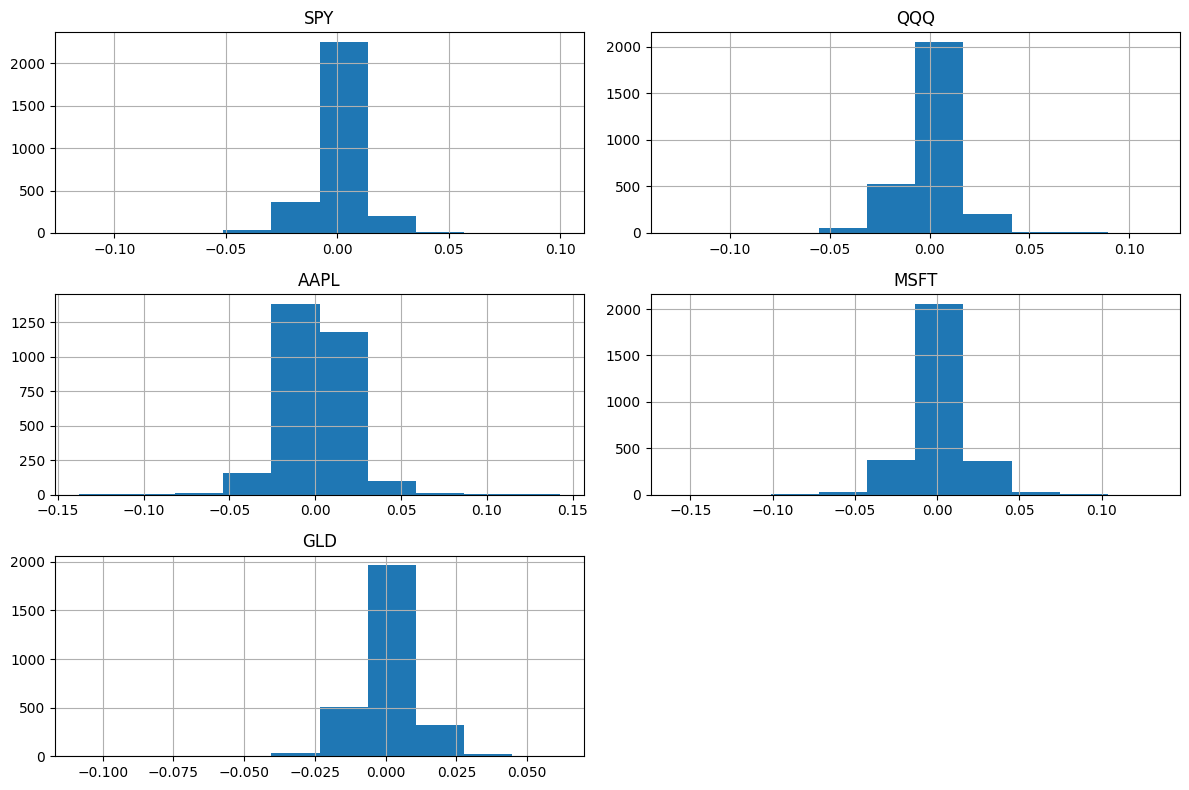

In [2]:
df.hist(figsize=(12, 8))

plt.tight_layout()

plt.savefig("../docs/returns_distributions.png")

plt.show()

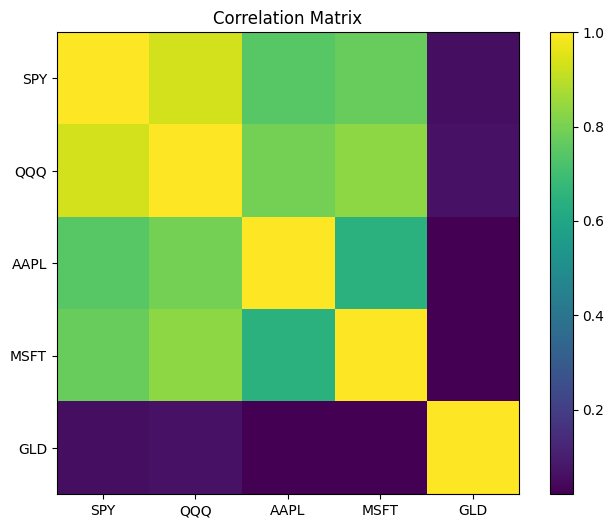

In [3]:
correlation = df.corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.savefig("../docs/correlation_matrix.png")

plt.show()

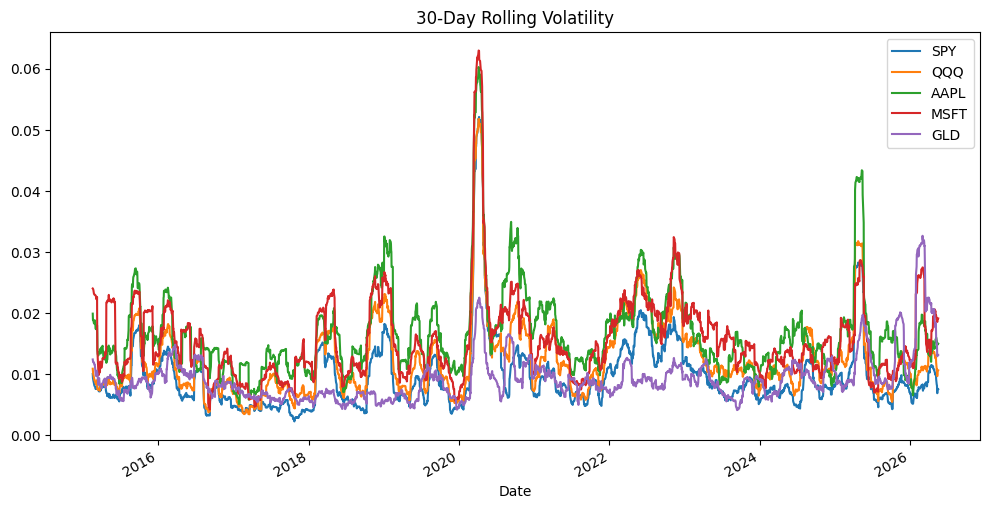

In [4]:
rolling_vol = df.rolling(30).std()

rolling_vol.plot(figsize=(12, 6))

plt.title("30-Day Rolling Volatility")

plt.savefig("../docs/rolling_volatility.png")

plt.show()

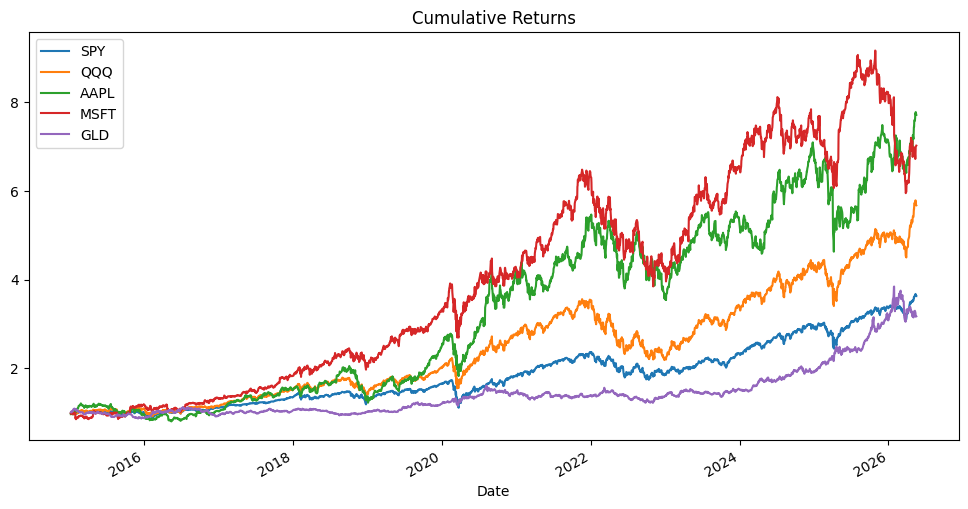

In [5]:
cumulative = (1 + df).cumprod()

cumulative.plot(figsize=(12, 6))

plt.title("Cumulative Returns")

plt.savefig("../docs/cumulative_returns.png")

plt.show()

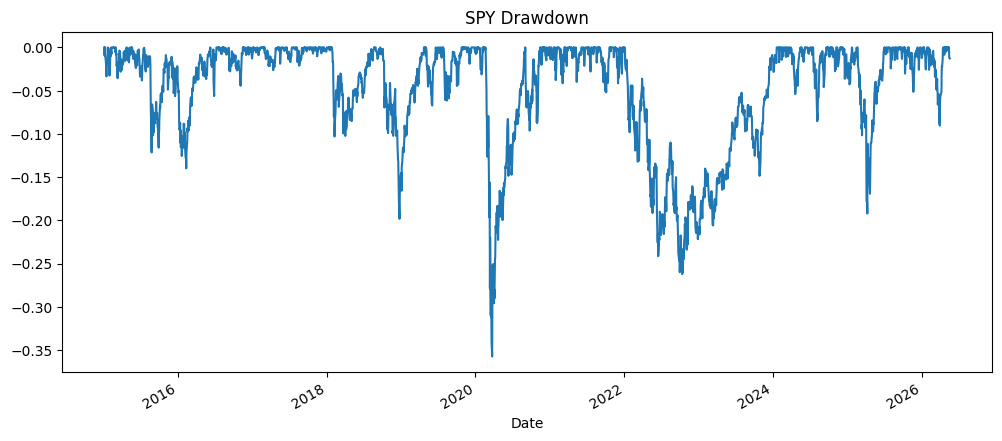

In [6]:
spy = cumulative["SPY"]

rolling_max = spy.cummax()

drawdown = (spy - rolling_max) / rolling_max

drawdown.plot(figsize=(12, 5))

plt.title("SPY Drawdown")

plt.savefig("../docs/spy_drawdown.png")

plt.show()

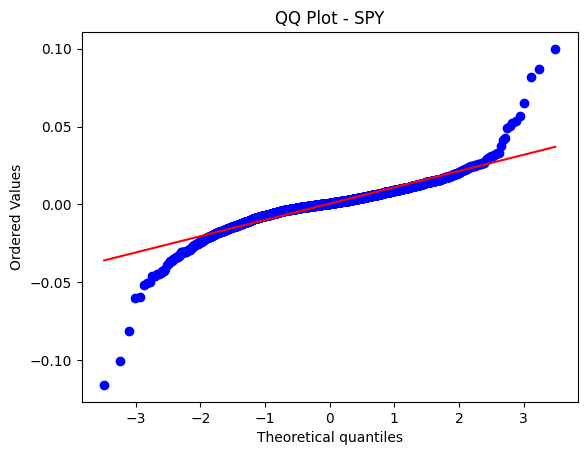

In [7]:
from scipy import stats

stats.probplot(df["SPY"], dist="norm", plot=plt)

plt.title("QQ Plot - SPY")

plt.savefig("../docs/qq_plots.png")

plt.show()